In [1]:
%run part01_data_preparation.ipynb

C:\Users\Alysson\Documents\Projects\Hotel-Booking-Cancelation\data\hotel_bookings.csv
C:\Users\Alysson\Documents\Projects\Hotel-Booking-Cancelation\notebooks\Hotel Booking.ipynb
C:\Users\Alysson\Documents\Projects\Hotel-Booking-Cancelation\notebooks\part01_data_preparation.ipynb
C:\Users\Alysson\Documents\Projects\Hotel-Booking-Cancelation\notebooks\part03_data_preprocessing.ipynb
C:\Users\Alysson\Documents\Projects\Hotel-Booking-Cancelation\notebooks\.ipynb_checkpoints\part01_data_preparation-checkpoint.ipynb
C:\Users\Alysson\Documents\Projects\Hotel-Booking-Cancelation\notebooks\.ipynb_checkpoints\part03_data_preprocessing-checkpoint.ipynb
C:\Users\Alysson\Documents\Projects\Hotel-Booking-Cancelation\rascunho\tables.txt
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 119390 entries, 0 to 119389
Data columns (total 32 columns):
 #   Column                          Non-Null Count   Dtype  
---  ------                          --------------   -----  
 0   hotel                       

In [8]:
import numpy as np
from matplotlib import pyplot as plt
%matplotlib inline
import pandas as pd
import seaborn as sns
import scipy.stats as stats
from scipy.stats import norm

### Machine Learning Libraries ###
from sklearn.model_selection import cross_val_score, cross_val_predict, GridSearchCV, KFold, cross_validate
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import LabelEncoder, StandardScaler, OneHotEncoder, MinMaxScaler 
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.ensemble import GradientBoostingClassifier
from xgboost import XGBClassifier
from sklearn.compose import ColumnTransformer
from sklearn.metrics import make_scorer, accuracy_score, recall_score, precision_score, mean_squared_error, f1_score
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, roc_auc_score, roc_curve, auc 
from sklearn.decomposition import PCA
from sklearn.feature_selection import SelectKBest, chi2, SelectFromModel, VarianceThreshold, SelectPercentile
from sklearn import set_config

from sklearn.impute import SimpleImputer

In [91]:
data_prep = data.copy()

In [92]:
drop_num_features = ['is_canceled']
drop_cat_features = ['reservation_status','reservation_status_date']

selected_features = data_prep.columns.drop(drop_num_features, drop_num_features)

In [93]:
data_prep

,hotel,is_canceled,lead_time,arrival_date_year,arrival_date_month,arrival_date_week_number,arrival_date_day_of_month,stays_in_weekend_nights,stays_in_week_nights,adults,...,customer_type,adr,required_car_parking_spaces,total_of_special_requests,reservation_status,reservation_status_date,adr_pp,people,kids,days_stay
0,Resort Hotel,0,342,2015,July,27,1,0,0,2,...,Transient,0.00,0,0,Check-Out,2015-07-01,0.000000,2,0,0
1,Resort Hotel,0,737,2015,July,27,1,0,0,2,...,Transient,0.00,0,0,Check-Out,2015-07-01,0.000000,2,0,0
2,Resort Hotel,0,7,2015,July,27,1,0,1,1,...,Transient,75.00,0,0,Check-Out,2015-07-02,75.000000,1,0,1
3,Resort Hotel,0,13,2015,July,27,1,0,1,1,...,Transient,75.00,0,0,Check-Out,2015-07-02,75.000000,1,0,1
4,Resort Hotel,0,14,2015,July,27,1,0,2,2,...,Transient,98.00,0,1,Check-Out,2015-07-03,49.000000,2,0,2
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
119385,City Hotel,0,23,2017,August,35,30,2,5,2,...,Transient,96.14,0,0,Check-Out,2017-09-06,48.070000,2,0,7
119386,City Hotel,0,102,2017,August,35,31,2,5,3,...,Transient,225.43,0,2,Check-Out,2017-09-07,75.143333,3,0,7
119387,City Hotel,0,34,2017,August,35,31,2,5,2,...,Transient,157.71,0,4,Check-Out,2017-09-07,78.855000,2,0,7
119388,City Hotel,0,109,2017,August,35,31,2,5,2,...,Transient,104.40,0,0,Check-Out,2017-09-07,52.200000,2,0,7


In [94]:
numerical =  data_prep.select_dtypes(include=["number","int64"]).drop(drop_num_features, axis=1)
numerical_features = numerical.columns

In [95]:
categorical = data_prep.select_dtypes(include=["category","object","datetime"]).drop(drop_cat_features, axis=1)
categorical_features = categorical.columns

In [96]:
seed = 7

lr = LogisticRegression(random_state=seed)
rf = RandomForestClassifier(random_state=seed)
xgb = XGBClassifier(max_depth=4, min_child_weight = 1, gamma=0, random_state=seed)



#selection = SelectPercentile(chi2, percentile=50)

preprocessor = ColumnTransformer(transformers=
    [
        ('std', MinMaxScaler(), numerical_features),
        ('ohe', OneHotEncoder(handle_unknown='ignore'), categorical_features), #sparse=False, drop='if_binary',
       # ('drop_features', 'drop', drop_features)
        
    ], remainder="drop"
)


pipeline_lr = Pipeline(steps=[('preprocessor', preprocessor),
                              #('selection', selection),
              ('classifier', lr)
])


pipeline_rf = Pipeline(steps=[('preprocessor', preprocessor),
                           #   ('selection', selection),
              ('classifier', rf)
])


pipeline_xgb = Pipeline(steps=[('preprocessor', preprocessor),
                              # ('selection', selection),
              ('classifier', xgb)
                        
])

pipeline_lr

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('std', MinMaxScaler(),
                                                  Index(['lead_time', 'arrival_date_year', 'arrival_date_week_number',
       'arrival_date_day_of_month', 'stays_in_weekend_nights',
       'stays_in_week_nights', 'adults', 'children', 'babies',
       'is_repeated_guest', 'previous_cancellations',
       'previous_bookings_not_canceled', 'booking_chang...
       'total_of_special_requests', 'adr_pp', 'people', 'kids', 'days_stay'],
      dtype='object')),
                                                 ('ohe',
                                                  OneHotEncoder(handle_unknown='ignore'),
                                                  Index(['hotel', 'arrival_date_month', 'meal', 'country', 'market_segment',
       'distribution_channel', 'reserved_room_type', 'assigned_room_type',
       'deposit_type', 'customer_type'],
      dtype='object'))])),
                ('classifier', LogisticRegression(random_state=7))])

In [106]:
# pipelines = [pipeline_lr, pipeline_rf, pipeline_xgb]
# pipe_dict = {0:'Logistic Regression', 1:'Random Forest', 2:'XGBoost'}

pipelines = [pipeline_lr, pipeline_xgb]
pipe_dict = {0:'Logistic Regression', 1:'XGBoost'}

In [107]:
target = 'is_canceled' 

In [108]:
selected_features

Index(['hotel', 'lead_time', 'arrival_date_year', 'arrival_date_month',
       'arrival_date_week_number', 'arrival_date_day_of_month',
       'stays_in_weekend_nights', 'stays_in_week_nights', 'adults', 'children',
       'babies', 'meal', 'country', 'market_segment', 'distribution_channel',
       'is_repeated_guest', 'previous_cancellations',
       'previous_bookings_not_canceled', 'reserved_room_type',
       'assigned_room_type', 'booking_changes', 'deposit_type', 'agent',
       'company', 'days_in_waiting_list', 'customer_type', 'adr',
       'required_car_parking_spaces', 'total_of_special_requests',
       'reservation_status', 'reservation_status_date', 'adr_pp', 'people',
       'kids', 'days_stay'],
      dtype='object')

In [109]:
y = data_prep[target]
X = data_prep[selected_features]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.3, shuffle=True, random_state=7)
X_train.shape, y_train.shape, X_test.shape, y_test.shape

((83446, 35), (83446,), (35763, 35), (35763,))

In [110]:
len(selected_features)

35

In [111]:
len(numerical_features), len(categorical_features)

(23, 10)

In [112]:
def CM(y_test, prediction):
    print("Confusion Matrix:")
    labels = ["Non-canceled", "Canceled"]
    cm = confusion_matrix(y_test, prediction)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=labels)
    disp.plot(cmap="binary", values_format="d")  
    plt.show() 

In [113]:
number_folds = 4
Kfold = KFold(n_splits=number_folds, shuffle=True, random_state=seed)

*****************************************************
Machine Learning algorithm: Logistic Regression
*****************************************************


Confusion Matrix:


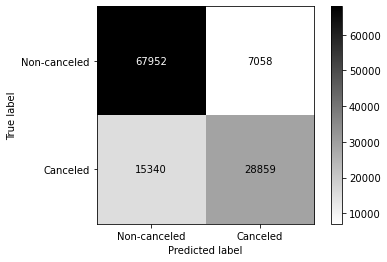



 fit_time : [0.78097725 0.78897715 0.77997541 0.79297638],  0.7857265472412109 +/- 0.005448803132168952
 score_time : [0.09599566 0.08999729 0.08899784 0.0879972 ],  0.09074699878692627 +/- 0.003111732269558165
 test_Accuracy : [0.80944871 0.81759613 0.81125428 0.81014697],  0.8121115239856955 +/- 0.003231325431551061
 test_Precision : [0.80350719 0.8039801  0.80408163 0.80237908],  0.8034870021083986 +/- 0.0006753934297059781
 test_f1 : [0.71569462 0.72792793 0.721576   0.71650466],  0.7204258023875365 +/- 0.004882732657078332
 test_Recall : [0.64518458 0.66502058 0.65442629 0.64723454],  0.6529664978187222 +/- 0.0077595954501433395


*****************************************************
Machine Learning algorithm: XGBoost
*****************************************************


Confusion Matrix:


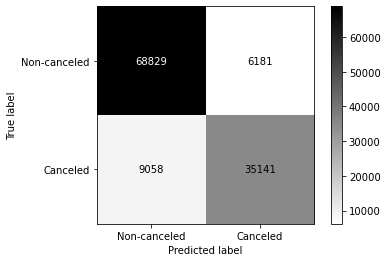



 fit_time : [1.56295347 1.53795385 1.53895259 1.55695224],  1.5492030382156372 +/- 0.010962896450984836
 score_time : [0.15199733 0.14699721 0.14699769 0.14499807],  0.14774757623672485 +/- 0.0025858038773035933
 test_Accuracy : [0.87105325 0.87433729 0.87145158 0.87182068],  0.8721657015196156 +/- 0.0012828059463338016
 test_Precision : [0.84721689 0.85176125 0.85119677 0.85154198],  0.8504292229988395 +/- 0.0018655251287659745
 test_f1 : [0.8212475  0.82297329 0.8221531  0.82087593],  0.8218124554333568 +/- 0.0008154516197169422
 test_Recall : [0.79682282 0.79606767 0.79502604 0.79234181],  0.7950645849504862 +/- 0.0016965070881484695


Wall time: 23.4 s


In [114]:
%%time

scoring = { 'Accuracy': make_scorer(accuracy_score),
            'Precision': make_scorer(precision_score),
            'f1': make_scorer(f1_score),
            'Recall': make_scorer(recall_score)}


np.random.seed(7)

score_metrics_cv = pd.DataFrame(columns=['Method','Accuracy','Precision','Recall','F1 Score'])

for i,model in enumerate(pipelines): 
    print('*' * 53) 
    print(f"Machine Learning algorithm: {pipe_dict[i]}") 
    print('*' * 53)     
    model.fit(X_train,y_train)
    y_pred = cross_val_predict(model, X, y, cv=Kfold, method='predict')
    print("\n")      
    CM(y,y_pred) 
    print("\n") 
    
    scores = cross_validate(model, X, y, cv = Kfold, scoring=scoring)
    for chave, valor in scores.items():
        print(f" {chave} : {valor},  {valor.mean()} +/- {valor.std()}") 
        
    print("\n") 
    score_metrics_cv.loc[i] = (pipe_dict[i], scores.get('test_Accuracy').mean(), 
                               scores.get('test_Precision').mean(),
                               scores.get('test_f1').mean(), 
                               scores.get('test_Recall').mean())